In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus = [
    'This is the first document.',
    'This document is the second document.',
    'And this is the third one.',
    'Is this the first document?',
]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21 stored elements and shape (4, 9)>

In [3]:
vectorizer.get_feature_names_out()

array(['and', 'document', 'first', 'is', 'one', 'second', 'the', 'third',
       'this'], dtype=object)

In [5]:
import numpy as np
output = np.array(X.todense())

In [7]:
import pandas as pd
df = pd.DataFrame(output, columns=vectorizer.get_feature_names_out())


In [19]:
df

,and,document,first,is,one,second,the,third,this
0,0.000000,0.469791,0.580286,0.384085,0.000000,0.000000,0.384085,0.000000,0.384085
1,0.000000,0.687624,0.000000,0.281089,0.000000,0.538648,0.281089,0.000000,0.281089
2,0.511849,0.000000,0.000000,0.267104,0.511849,0.000000,0.267104,0.511849,0.267104
3,0.000000,0.469791,0.580286,0.384085,0.000000,0.000000,0.384085,0.000000,0.384085


In [24]:
query = "I am not happy."
query_vector = vectorizer.transform([query])

In [25]:
def search(query_vector, X, top_n=2):
    # compute euclidean distance
    distances = np.linalg.norm(X - query_vector.toarray(), axis=1)
    # Get the indices of the top_n most similar documents
    top_indices = np.argsort(distances)[:top_n]
    return top_indices, distances[top_indices]


search(query_vector, X, top_n=2)

(array([0, 1]), array([1., 1.]))

In [26]:
corpus[0]

'This is the first document.'

In [27]:
corpus[3]

'Is this the first document?'

In [33]:
# word embedding model
import gensim.downloader as api
wiki_model = api.load("glove-wiki-gigaword-50")

In [34]:
wiki_model.vector_size

50

In [36]:
loan_v = wiki_model["loan"]
bank_v = wiki_model["bank"]
dhoni_v = wiki_model["dhoni"]

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

loan_v = loan_v.reshape(1, -1)
bank_v = bank_v.reshape(1, -1)
dhoni_v = dhoni_v.reshape(1, -1)

cosine_similarity(loan_v, bank_v), cosine_similarity(loan_v, dhoni_v)

(array([[0.67568016]], dtype=float32), array([[-0.02519299]], dtype=float32))

In [38]:
loan_v

array([[ 0.93484  ,  0.40451  ,  0.10856  , -0.61954  , -0.6922   ,
         0.32119  , -0.70885  ,  0.071233 , -0.33484  ,  0.77159  ,
        -0.050077 ,  1.1446   ,  0.01926  , -1.0259   ,  0.85535  ,
        -0.081615 ,  0.19649  , -0.051262 ,  0.40104  ,  0.87255  ,
         0.95371  , -0.87009  , -0.81569  , -0.24765  , -1.444    ,
        -0.88613  ,  1.5144   , -0.014284 , -0.48024  , -0.32289  ,
         3.0058   ,  0.49409  ,  0.72916  ,  0.60891  ,  0.59544  ,
         0.49731  , -0.0057787, -0.21278  ,  0.94938  , -2.1685   ,
         0.12593  , -0.56819  ,  0.50355  ,  0.013716 , -1.0131   ,
        -0.46806  ,  0.17305  ,  1.6204   ,  0.60405  ,  0.063104 ]],
      dtype=float32)

In [51]:
words = ["loans", "credit", "finance", "money", "gold", "river", "banana",'rahul','dhoni','virat','borrow']
word_vectors= [wiki_model[word] for word in words]
word_vectors[0]

array([ 0.88557 , -0.099846,  0.87289 , -0.61665 , -0.72915 ,  0.6552  ,
       -0.55611 , -0.26826 , -0.71744 ,  0.93427 , -0.16438 ,  1.0303  ,
        0.59328 , -0.32384 ,  0.67821 ,  0.45258 , -0.11809 , -0.013178,
        1.3043  ,  0.439   ,  1.3129  , -0.85867 , -0.4282  , -0.33765 ,
       -0.85213 , -0.75945 ,  0.81165 , -0.1273  , -0.13318 , -0.29429 ,
        3.4526  ,  0.4574  ,  1.3984  ,  0.80431 ,  0.76795 ,  0.22108 ,
       -0.56603 , -0.45018 ,  0.60762 , -1.6825  , -0.90308 , -0.50345 ,
        1.2368  ,  0.47151 , -0.72239 , -0.87735 , -0.38407 ,  1.4531  ,
        0.84765 , -0.23892 ], dtype=float32)

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points_2d = pca.fit_transform(word_vectors)


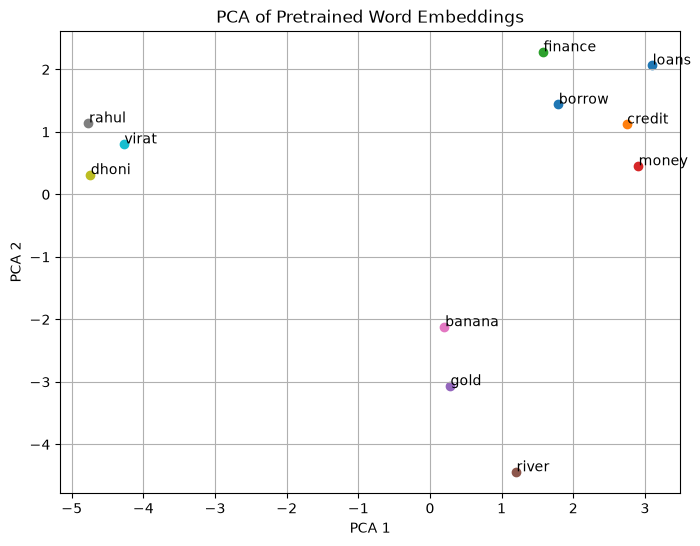

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x = points_2d[i, 0]
    y = points_2d[i, 1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

plt.title("PCA of Pretrained Word Embeddings")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [30]:
# pip install gensim